In [1]:
# glob и zipfile — встроенные модули Python, ставить их не нужно
%pip install -q pandas scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: C:\Users\Iaroslav\AppData\Local\Temp\claude\C--Users-Iaroslav-Desktop--------ForkIT----------------v2\4f485f0d-e3d3-4c1f-874f-c70487cdeebc\scratchpad\nbenv\Scripts\python.exe -m pip install --upgrade pip


In [2]:
import glob, zipfile
import pandas as pd
import pickle
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [3]:
import os, json, urllib.request

# тетрадку открывают и из клона репозитория, и отдельно (Colab) — во втором случае рядом нет архивов,
# и мы скачиваем их из репозитория; список файлов берём у GitHub, а не перечисляем месяцы руками
REPO = "Tsezzar/Machine_Learning_Lessons"
DATA_DIR = "us-flights-2026-raw/monthly-zips"

if not glob.glob(f"{DATA_DIR}/*.zip"):
    os.makedirs(DATA_DIR, exist_ok=True)
    with urllib.request.urlopen(f"https://api.github.com/repos/{REPO}/contents/{DATA_DIR}") as r:
        files = [f for f in json.load(r) if f["name"].endswith(".zip")]
    for f in files:
        print("скачиваю", f["name"])
        urllib.request.urlretrieve(f["download_url"], os.path.join(DATA_DIR, f["name"]))

print(len(glob.glob(f"{DATA_DIR}/*.zip")), "архивов в", DATA_DIR)

6 архивов в us-flights-2026-raw/monthly-zips


In [4]:
pd.set_option("mode.string_storage", "python")
# ArrDelay и ArrDel15 не читаем: их узнают только после прилёта, а мы прогнозируем вылет
COLS = ["FlightDate", "Reporting_Airline", "Origin", "Dest", "CRSDepTime",
        "CRSElapsedTime", "Distance", "DepDelay", "Cancelled"]


def read(path):
    with zipfile.ZipFile(path) as z:
        name = [n for n in z.namelist() if n.endswith(".csv")][0]
        return pd.read_csv(z.open(name), usecols=COLS)


df = pd.concat([read(f) for f in sorted(glob.glob(f"{DATA_DIR}/*.zip"))],
               ignore_index=True)

# перенаправленные рейсы вылетели, задержка вылета у них настоящая — отсеиваем только отменённые
df = df[df.Cancelled == 0].drop(columns=["Cancelled"])
df = df.dropna(subset=["DepDelay", "CRSElapsedTime"])

df["FlightDate"] = pd.to_datetime(df.FlightDate)
df["Month"] = df.FlightDate.dt.month
df["DayOfWeek"] = df.FlightDate.dt.dayofweek
df["DepHour"] = df.CRSDepTime // 100 % 24
df["DepDel15"] = (df.DepDelay >= 15).astype(int)

df.to_pickle("flights_2026.pkl")
print(df.shape)
print(df.head())

(3412289, 12)
  FlightDate Reporting_Airline Origin Dest  CRSDepTime  DepDelay  \
0 2026-01-01                AA    JFK  LAX         700      -3.0   
1 2026-01-02                AA    JFK  LAX         700      -6.0   
2 2026-01-03                AA    JFK  LAX         700      -2.0   
3 2026-01-04                AA    JFK  LAX         729      -4.0   
4 2026-01-05                AA    JFK  LAX         729      -9.0   

   CRSElapsedTime  Distance  Month  DayOfWeek  DepHour  DepDel15  
0           381.0    2475.0      1          3        7         0  
1           381.0    2475.0      1          4        7         0  
2           381.0    2475.0      1          5        7         0  
3           387.0    2475.0      1          6        7         0  
4           387.0    2475.0      1          0        7         0  


## Постановка

Прогнозируем **задержку вылета** `DepDelay` (минуты) по тому, что известно заранее: дата, час вылета по расписанию, авиакомпания, аэропорты, дистанция, время в пути по расписанию.
`ArrDelay` и `ArrDel15` в данные не берём — их узнают только после прилёта, в признаках это была бы утечка ответа.

## Анализ данных

In [5]:
import matplotlib.pyplot as plt

df = pd.read_pickle("flights_2026.pkl")

print("рейсов:", len(df), "| вылетают с задержкой 15+ мин:", round(df.DepDel15.mean(), 2),
      "| вылетают раньше расписания:", round((df.DepDelay < 0).mean(), 2))
print("DepDelay: медиана", df.DepDelay.median(), "мин, среднее", round(df.DepDelay.mean(), 1),
      "мин, максимум", df.DepDelay.max(), "мин")
print("\nкорреляция с DepDelay:")
print(df.corr(numeric_only=True).DepDelay.drop(["DepDelay", "DepDel15"]).sort_values(ascending=False).round(2))

рейсов: 3412289 | вылетают с задержкой 15+ мин: 0.23 | вылетают раньше расписания: 0.57
DepDelay: медиана -2.0 мин, среднее 13.8 мин, максимум 3339.0 мин

корреляция с DepDelay:


CRSDepTime        0.10
DepHour           0.10
Month             0.02
DayOfWeek         0.01
CRSElapsedTime    0.01
Distance          0.00
Name: DepDelay, dtype: float64


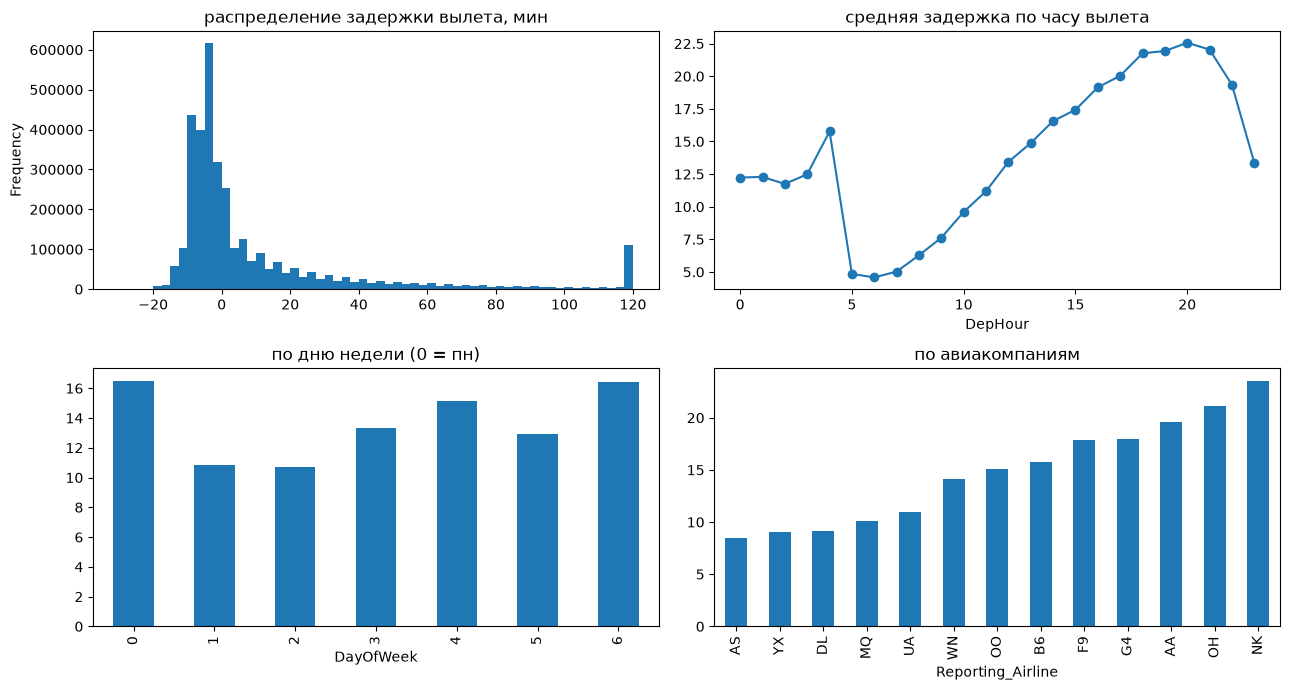

In [6]:
fig, ax = plt.subplots(2, 2, figsize=(13, 7))

df.DepDelay.clip(-30, 120).plot.hist(bins=60, ax=ax[0, 0], title="распределение задержки вылета, мин")
df.groupby("DepHour").DepDelay.mean().plot(ax=ax[0, 1], marker="o", title="средняя задержка по часу вылета")
df.groupby("DayOfWeek").DepDelay.mean().plot.bar(ax=ax[1, 0], title="по дню недели (0 = пн)")
df.groupby("Reporting_Airline").DepDelay.mean().sort_values().plot.bar(ax=ax[1, 1], title="по авиакомпаниям")

plt.tight_layout()
plt.show()

**Выводы:** медиана задержки вылета −2 мин: 57% рейсов уходят раньше расписания, на 15+ минут задерживаются 23%.
Среднее (13.8 мин) сильно больше медианы — длинный хвост: редкие задержки на часы (максимум 3339 мин) тянут среднее вверх.
Ни один признак, известный до вылета, линейно с задержкой почти не связан (корреляция не выше 0.10).
Заметнее всего час вылета: утренние рейсы (5–7 ч) задерживаются в среднем на ~5 мин, вечерние (18–21 ч) — на ~22 мин, задержки копятся в течение дня.
Авиакомпании различаются почти втрое: от 8 мин (AS) до 24 мин (NK). Понедельник и воскресенье хуже вторника и среды (16.5 против 10.7 мин).

# Модели

In [7]:
# в признаках только то, что известно до вылета: расписание, маршрут, авиакомпания
F = ["Month", "DayOfWeek", "DepHour", "Distance", "CRSElapsedTime",
     "Reporting_Airline", "Origin", "Dest"]

df = pd.read_pickle("flights_2026.pkl")
for c in ["Reporting_Airline", "Origin", "Dest"]:
    df[c] = df[c].astype("category").cat.codes

train = df[df.FlightDate < "2026-06-01"]
test = df[df.FlightDate >= "2026-06-01"]

base = DummyRegressor().fit(train[F], train.DepDelay)
m = HistGradientBoostingRegressor(max_iter=300, random_state=0).fit(train[F], train.DepDelay)

for name, p in [("baseline", base.predict(test[F])), ("модель", m.predict(test[F]))]:
    print(f"{name:9} MAE {mean_absolute_error(test.DepDelay, p):5.1f} мин   "
          f"R2 {r2_score(test.DepDelay, p):6.3f}")

baseline  MAE  27.5 мин   R2 -0.005
модель    MAE  25.3 мин   R2  0.031


## Сравнение моделей

In [8]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

# эвристика без модели: средняя задержка этой авиакомпании в этот час по обучающим месяцам
g = train.groupby(["Reporting_Airline", "DepHour"]).DepDelay.mean().rename("p")
heur = test.join(g, on=["Reporting_Airline", "DepHour"]).p.fillna(train.DepDelay.mean())

preds = {"среднее по авиакомпании и часу": heur.values, "бустинг": m.predict(test[F])}
for name, est in [("среднее", DummyRegressor()),
                  ("медиана", DummyRegressor(strategy="median")),
                  ("линейная", LinearRegression()),
                  ("дерево", DecisionTreeRegressor(max_depth=8, random_state=0)),
                  # метрика — MAE, а обычный бустинг учится на квадрате ошибки и тянет прогноз к среднему
                  ("бустинг, loss=MAE", HistGradientBoostingRegressor(loss="absolute_error",
                                                                     max_iter=300, random_state=0))]:
    preds[name] = est.fit(train[F], train.DepDelay).predict(test[F])

res = pd.DataFrame({n: {"MAE": mean_absolute_error(test.DepDelay, p),
                        "R2": r2_score(test.DepDelay, p)} for n, p in preds.items()}).T
res = res.sort_values("MAE")
res.round(3)

,MAE,R2
"бустинг, loss=MAE",22.258,-0.063
медиана,23.633,-0.098
бустинг,25.286,0.031
дерево,25.632,0.020
среднее по авиакомпании и часу,26.098,0.023
линейная,26.267,0.012
среднее,27.512,-0.005


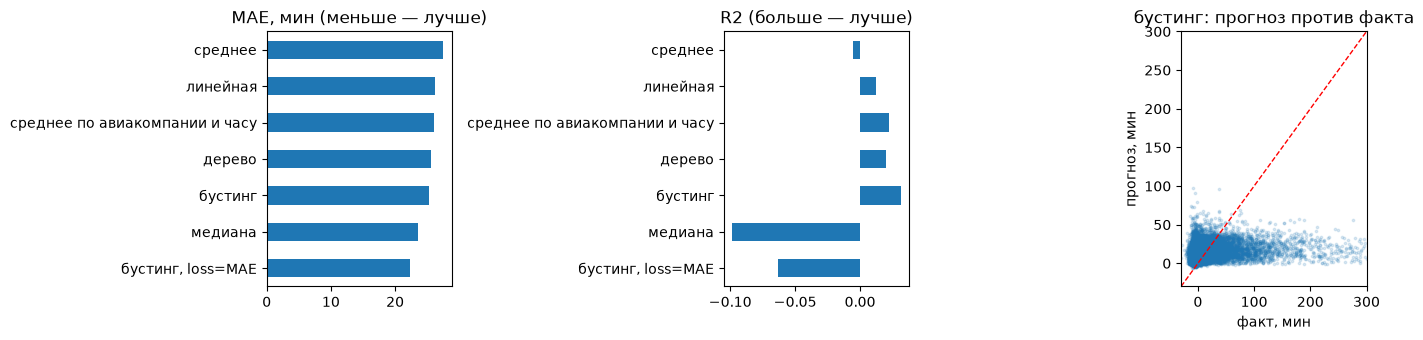

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.5))

res.MAE.plot.barh(ax=ax[0], title="MAE, мин (меньше — лучше)")
res.R2.plot.barh(ax=ax[1], title="R2 (больше — лучше)")

i = np.random.default_rng(0).choice(len(test), 15000, replace=False)
ax[2].scatter(test.DepDelay.values[i], preds["бустинг"][i], s=3, alpha=0.15)
ax[2].plot([-30, 300], [-30, 300], "r--", lw=1)
ax[2].set(title="бустинг: прогноз против факта", xlabel="факт, мин", ylabel="прогноз, мин",
          xlim=(-30, 300), ylim=(-30, 300))

plt.tight_layout()
plt.show()

**Выводы:** по признакам расписания задержку вылета в минутах почти не предсказать: лучший R2 — 0.031 у обычного бустинга, модель объясняет 3% разброса.
Простая эвристика «средняя задержка этой авиакомпании в этот час» почти не уступает (R2 0.023) — всё, что модели нашли, это час вылета и авиакомпания.

Метрика и функция потерь должны совпадать. Обычные модели учатся на квадратичной ошибке и тянут прогноз к среднему (13.8 мин),
а при длинном хвосте MAE минимизирует медиана (−2 мин) — поэтому константа-медиана обходит их по MAE (23.6 мин).
Бустинг с `loss="absolute_error"` учится ровно на MAE и даёт лучший результат — 22.3 мин, на 1.4 мин лучше медианы.
Его R2 при этом отрицательный: он прогнозирует около типичного значения и не пытается угадать редкие большие задержки — это цена оптимизации MAE, а не ошибка.

Вероятная причина низкого качества — главное в данных отсутствует: погода, загрузка аэропорта, опоздание предыдущего рейса того же самолёта.
К тому же тестовый июнь тяжелее обучающих месяцев: средняя задержка 17.6 мин против 10.7–17.0 в январе–мае.
Более посильная постановка на этих же признаках — классификация «задержится ли вылет на 15+ минут» (`DepDel15`).
